In [ ]:
import numpy as np
import torch
import time
import matplotlib.pyplot as plt
import statsmodels.api as sm
from google.colab import drive
drive.mount('/content/drive')

FOLDER_PATH = '/content/drive/MyDrive/Colab Notebooks/data_model_davies'

Mounted at /content/drive


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Numerical parameters
nlat = 78
nlon = 71
nz = 500 # Initial number of rioters

Lr = 6 # most recent time steps in our discretised temporal scheme
Lp = 12 # response lag of the police units

Nt = 500 # Rate at which individuals choose to participate at time t
Ntt = 10

dt = 0.1 # delta time
sim_time = 0.0 # init time

In [ ]:
# Simulation parameters

# alpha_r: Attractiveness of a retail site to rioters (It is the parameter associated with the size of the retail location.)
# beta_r: Distance decay parameter for rioters (It influences how the distance between a rioter's residence and a potential
#         target affects the attractiveness of that target)
# gamma_r: Deterrent effect of police presence (It is a factor in the term that modifies the attractiveness of location j based
#          on the number of police officers and rioters, so it is a measure of how much the presence of police will deter a rioter)

alpha_r = 0.5
beta_r = 0.5
gamma_r = 0.11

mu = 1.0 # This is an exponent in the function for the probability of rioting in an area, related to how deprivation affects the likelihood of rioting

# alpha_p: Attractiveness of a location to police. It influences how police resources are allocated based on the characteristics of the location.
# gamma_p: Impact of the number of rioters on the police requirement at a site.

alpha_p = 1.0
gamma_p = 0.01

eta = 0.005 # Infection rate. It determines how quickly individuals are influenced by the ongoing disorder and become active rioters
tau = 0.75 # Arrest rate parameter. It determines how quickly rioters are arrested by police when they are present
Ptotal = 500.0  # Total number of police forces

In [ ]:
# Data sources

# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# i: Residential Área
# j: Retail Center (Potential Riot Site)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")  # Ponderated distances (the distance between the centroids of i and j)
Dj_cl= np.loadtxt(f"{FOLDER_PATH}/data_sosafe.dat") # Data from SOSAFE (real data)

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Ai = np.zeros((nlat, nlon), "d")  # Active population
Ci = np.zeros((nlat, nlon), "d")  # Capture rate
rho = np.ones((nlat, nlon), "d")  # Deprivation distribution (is a measure of the deprivation in i)

Rj = np.zeros(nz, "d")  # Rioters (Ri: the number of rioters whose residece in in a given zone i)
# Rj = np.loadtxt('Rj_init.dat') # Initial 100 rioters distribution
Pj = np.zeros(nz, "d")  # Police officers
We_ij = np.zeros((nlat, nlon, nz), "d")  # Benefit computation (We_ij: effective attractiveness)
fjdel = np.zeros((nz, Lr), "d")  # Delayed effect computation
Sij = np.zeros((nlat, nlon, nz), "d")  # Population flow between i and j (An estimate of the number of rioters from i who are participating in disorder in j at time t)
Dj = np.zeros(nz, "d")  # The number of rioters in j
Ddel = np.zeros((nz, Lp), "d")  # Police requirement, time-delayed
Dej = np.zeros(nz, "d")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks

def run_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau, Ptotal = 0.005, 0.75, 500.0
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = Ptotal * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    # x = np.arange(len(Rj_t))
    # y = Rj_t

    # # Detectar picos
    # y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
    # peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
    # peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
    # peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

    # # Filtrar los valores
    # x_peaks = x[peaks]
    # y_peaks = y[peaks]

    # # Interpolación lineal
    # linear_interpolation_Rj = np.interp(x, x_peaks, y_peaks)

    # scaler = MinMaxScaler()
    # Rj_t = scaler.fit_transform(linear_interpolation_Rj.reshape(-1, 1)).flatten()

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return Rj_t




In [ ]:
# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

# PSO parameters
beta_r = 0.1
gamma_r = 0.19482765
alpha_p = 0.97356374
gamma_p = 0.03415131

Rj_simulated = run_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p)

Starting loop ...
Total execution time:  3.4306094646453857


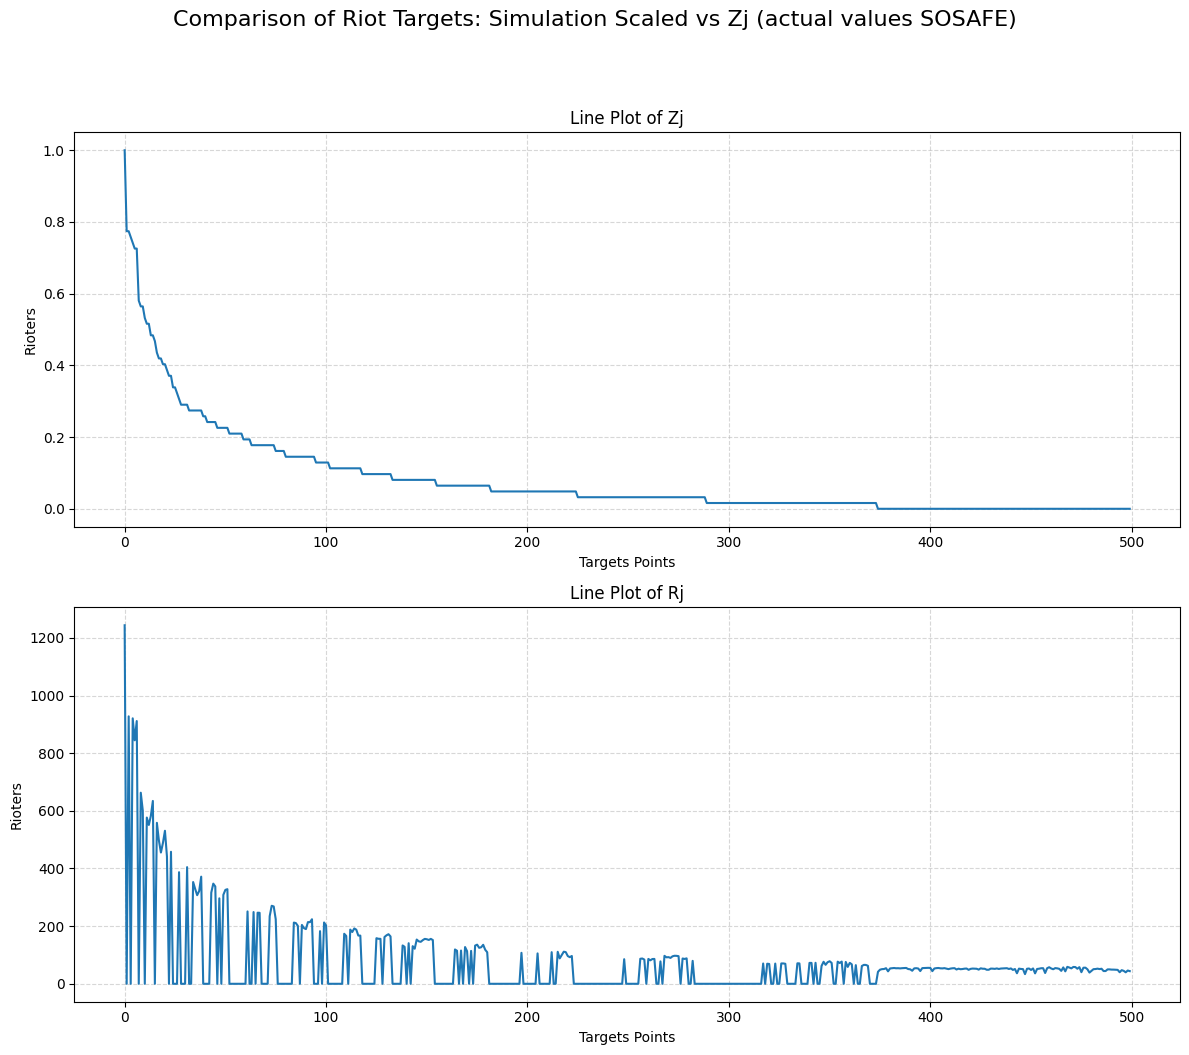

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def plot_results(Zj, Rj, algorithm):

    # Crear una figura con dos subplots verticales
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Agregar un título general
    fig.suptitle(f"Comparison of Riot Targets: Simulation {algorithm} vs Zj (actual values SOSAFE)", fontsize=16, y=1.05)

    # Primer subplot para Zj
    x1 = np.arange(len(Zj))
    y1 = Zj
    ax1.plot(x1, y1)
    ax1.set_xlabel('Targets Points')
    ax1.set_ylabel('Rioters')
    ax1.set_title('Line Plot of Zj')
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Segundo subplot para Rj
    x2 = np.arange(len(Rj))
    y2 = Rj
    ax2.plot(x2, y2)
    ax2.set_xlabel('Targets Points')
    ax2.set_ylabel('Rioters')
    ax2.set_title('Line Plot of Rj')
    ax2.grid(True, linestyle='--', alpha=0.5)

    # Ajustar el espaciado entre subplots
    plt.tight_layout()

    # Mostrar la figura
    plt.show()


scaler = MinMaxScaler()

Zj_t = torch.from_numpy(Zj).to(device)
real_scaled_data = scaler.fit_transform(Zj_t[:, 2].cpu().numpy().reshape(-1, 1)).flatten()

plot_results(real_scaled_data, Rj_simulated, "Scaled")

In [ ]:
diff_error = np.abs(real_scaled_data - Rj_simulated)

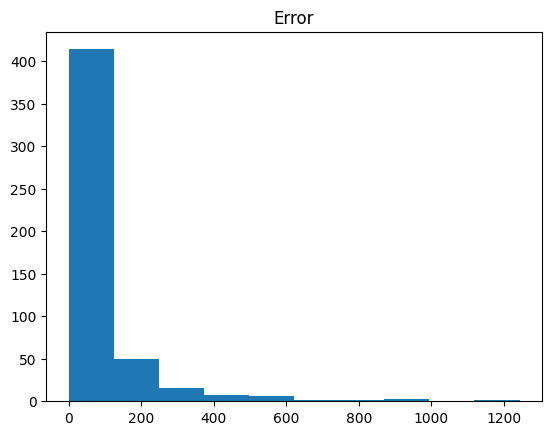

In [ ]:
plt.hist(diff_error)
plt.title("Error")
plt.show()

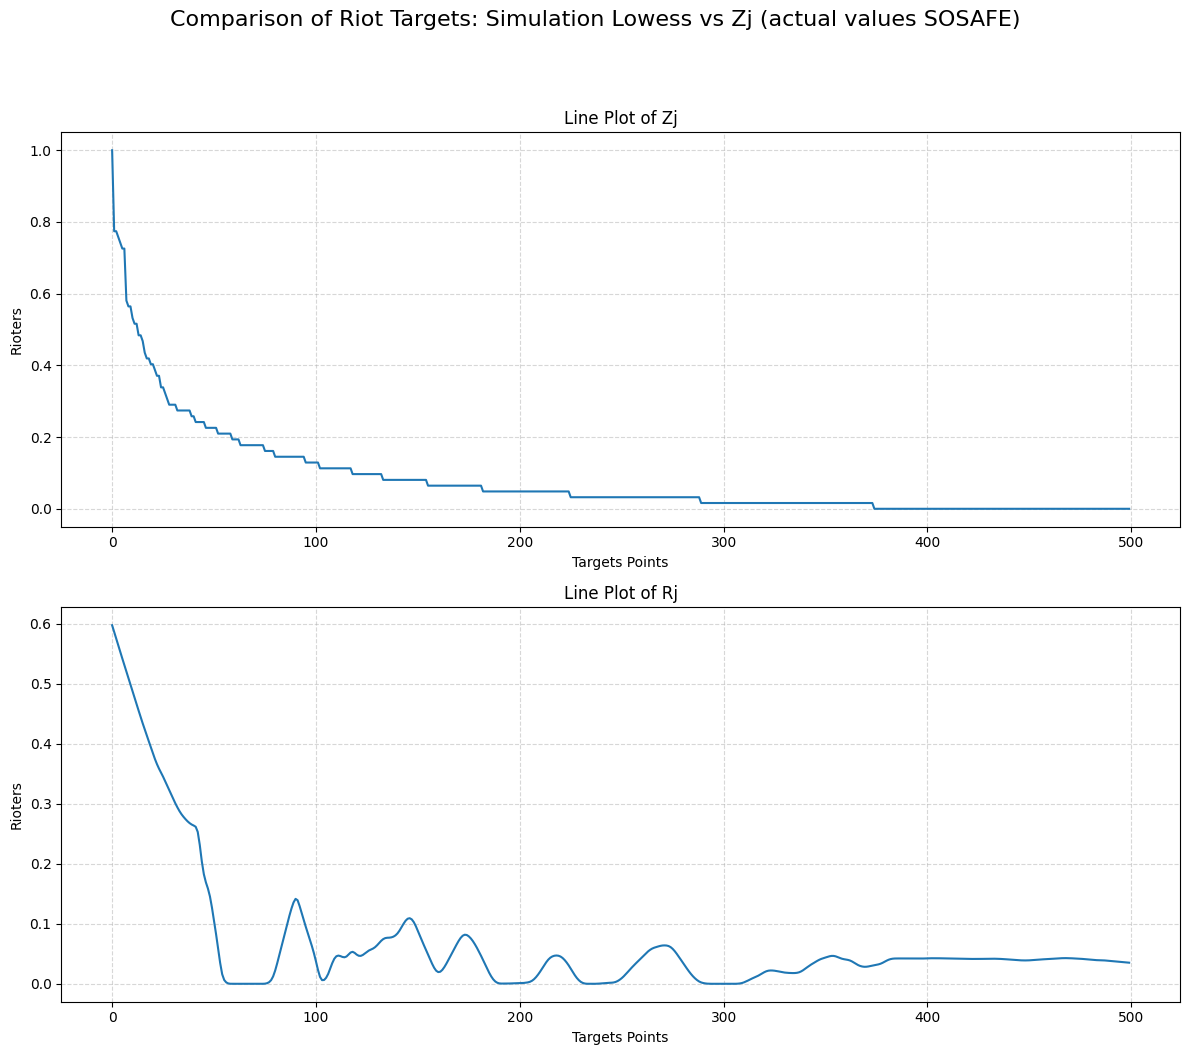

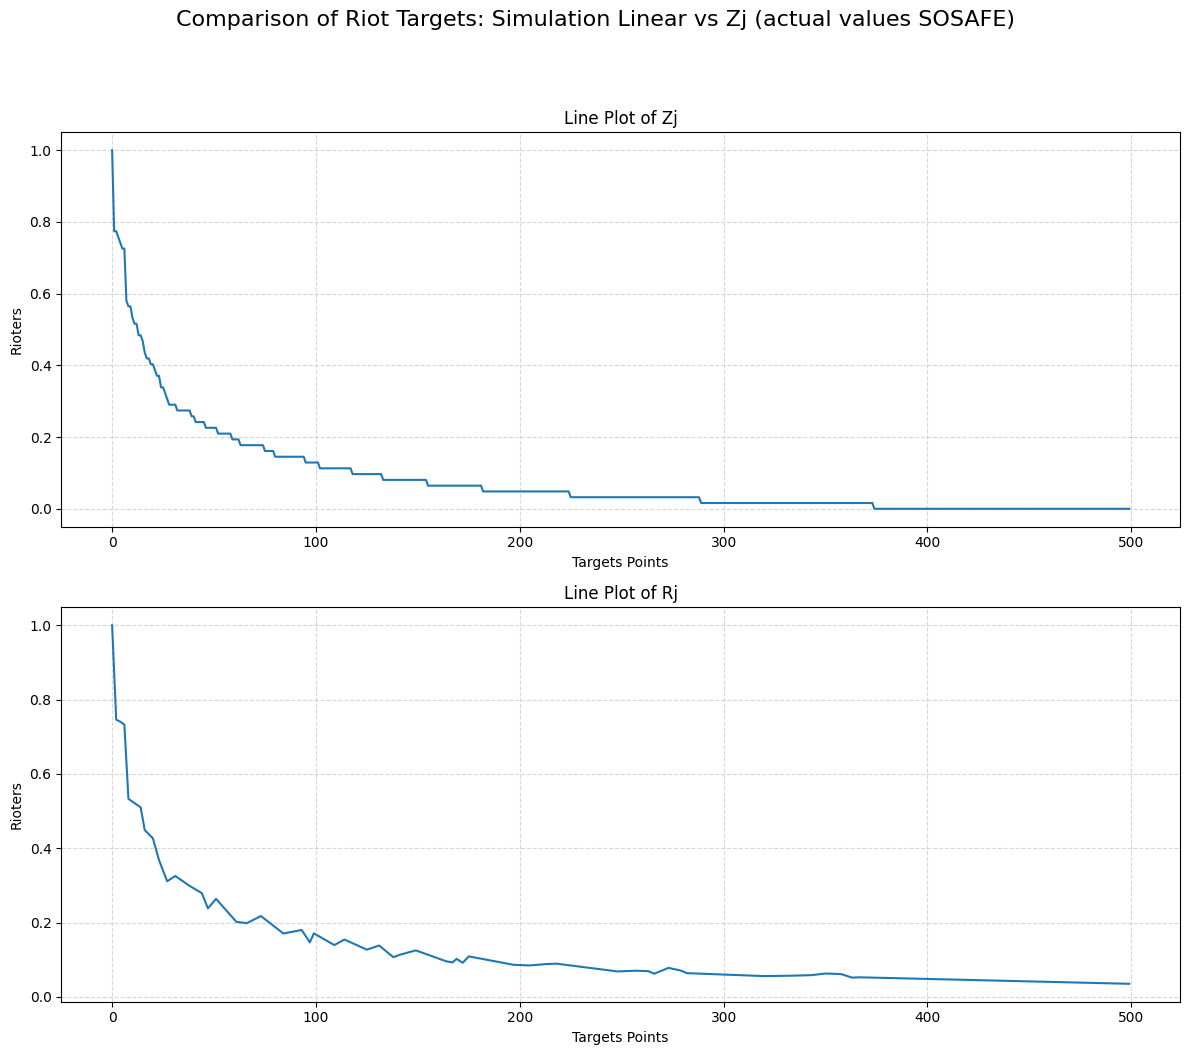

In [ ]:
# MinMax Scaler
scaler = MinMaxScaler()

# Nomalización MinMax
x = np.arange(len(Rj_simulated))
y = scaler.fit_transform(Rj_simulated.reshape(-1, 1)).flatten()

# Lowess
lowess = sm.nonparametric.lowess(y, x, frac=0.05)
lowess_interpolation_Rj = lowess[:, 1]

# Detectar picos
peaks, _ = find_peaks(y, prominence=0.05)  # Ajuste según la escala normalizada
peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

# Filtrar los valores
x_peaks = x[peaks]
y_peaks = y[peaks]

# Interpolación lineal
linear_interpolation_Rj = np.interp(x, x_peaks, y_peaks)

plot_results(real_scaled_data, lowess_interpolation_Rj, "Lowess")
plot_results(real_scaled_data, linear_interpolation_Rj, "Linear")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_errors_sklearn(predicted, real):
    predicted = predicted.flatten()
    real = real.flatten()

    mse = mean_squared_error(real, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(real, predicted)
    r2 = r2_score(real, predicted)

    # MAPE con manejo de valores cero
    # Calculamos MAPE solo para valores no cero
    non_zero_mask = (real != 0)
    if np.any(non_zero_mask):
        mape = np.mean(np.abs((real[non_zero_mask] - predicted[non_zero_mask]) / real[non_zero_mask])) * 100
    else:
        mape = np.nan  # o podrías establecer otro valor por defecto

    # SMAPE (Symmetric Mean Absolute Percentage Error)
    epsilon = 1e-10
    smape = np.mean(2 * np.abs(real - predicted) / (np.abs(real) + np.abs(predicted) + epsilon)) * 100

    metrics = {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "smape": smape,
        "r2": r2,
        "max_error": np.max(np.abs(real - predicted))
    }

    return metrics

def print_detailed_comparison_sklearn(predicted, real):
    metrics = calculate_errors_sklearn(predicted, real)

    print("Métricas de error:")
    print(f"RMSE: {metrics['rmse']:.4f}")
    print(f"MAE: {metrics['mae']:.4f}")
    print(f"MAPE mod: {metrics['mape']:.2f}%")
    print(f"SMAPE: {metrics['smape']:.2f}%")
    print(f"R² Score: {metrics['r2']:.4f}")
    print(f"Error máximo: {metrics['max_error']:.4f}")


In [ ]:
print("Interpolación Lineal")
print_detailed_comparison_sklearn(linear_interpolation_Rj, real_scaled_data)
print("\n")
print("Lowess")
print_detailed_comparison_sklearn(lowess_interpolation_Rj, real_scaled_data)

Interpolación Lineal
Métricas de error:
RMSE: 0.0396
MAE: 0.0384
MAPE mod: 103.48%
SMAPE: 92.86%
R² Score: 0.9123
Error máximo: 0.0988


Lowess
Métricas de error:
RMSE: 0.0625
MAE: 0.0419
MAPE mod: 57.89%
SMAPE: 110.59%
R² Score: 0.7808
Error máximo: 0.4025


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks

def run_simulation_ptotal(dij_sim, Ii, Zj, Ptotal):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau = 0.005, 0.75
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    # PSO parameters
    beta_r = 0.1
    gamma_r = 0.19482765
    alpha_p = 0.97356374
    gamma_p = 0.03415131

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = Sij_t.sum(dim=1).sum(dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = float(Ptotal) * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    x = np.arange(len(Rj_t))
    y = Rj_t

    # Detectar picos
    y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
    peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
    peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
    peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

    # Filtrar los valores
    x_peaks = x[peaks]
    y_peaks = y[peaks]

    # Interpolación lineal
    linear_interpolation_Rj = np.interp(x, x_peaks, y_peaks)

    scaler = MinMaxScaler()
    Rj_t = scaler.fit_transform(linear_interpolation_Rj.reshape(-1, 1)).flatten()

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return Rj_t

In [ ]:
ptotal_array = np.arange(0, 4001, 500) # Ptotal ranges from 500 to 4000 in steps of 500
Rj_simulated_ptotals = [run_simulation_ptotal(dij, Ii, Zj, ptotal) for ptotal in ptotal_array] # Store results

Starting loop ...
Total execution time:  3.205749034881592
Starting loop ...
Total execution time:  3.217790126800537
Starting loop ...
Total execution time:  3.2598257064819336
Starting loop ...
Total execution time:  3.2206814289093018
Starting loop ...
Total execution time:  3.2387194633483887
Starting loop ...
Total execution time:  3.2286689281463623
Starting loop ...
Total execution time:  3.2036426067352295
Starting loop ...
Total execution time:  3.2102913856506348
Starting loop ...
Total execution time:  3.2199409008026123


In [ ]:
errors = []
for i, result in enumerate(Rj_simulated_ptotals):
    error = np.linalg.norm(real_scaled_data-result).round(4)
    ptotal_qty = (i)*500
    print(f"Error (Ptotal = {ptotal_qty}) : {error}")
    errors.append(error)

Error (Ptotal = 0) : 0.5589
Error (Ptotal = 500) : 0.2443
Error (Ptotal = 1000) : 1.0634
Error (Ptotal = 1500) : 1.4397
Error (Ptotal = 2000) : 2.4145
Error (Ptotal = 2500) : 10.4754
Error (Ptotal = 3000) : 10.4754
Error (Ptotal = 3500) : 7.3832
Error (Ptotal = 4000) : 5.1864


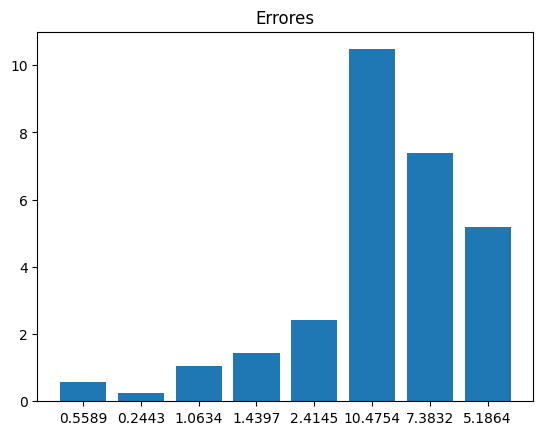

In [ ]:
def plot_errors(errors : list):

    plt.title("Errores")
    plt.bar([str(x) for x in errors], errors)
    plt.show()

plot_errors(errors)

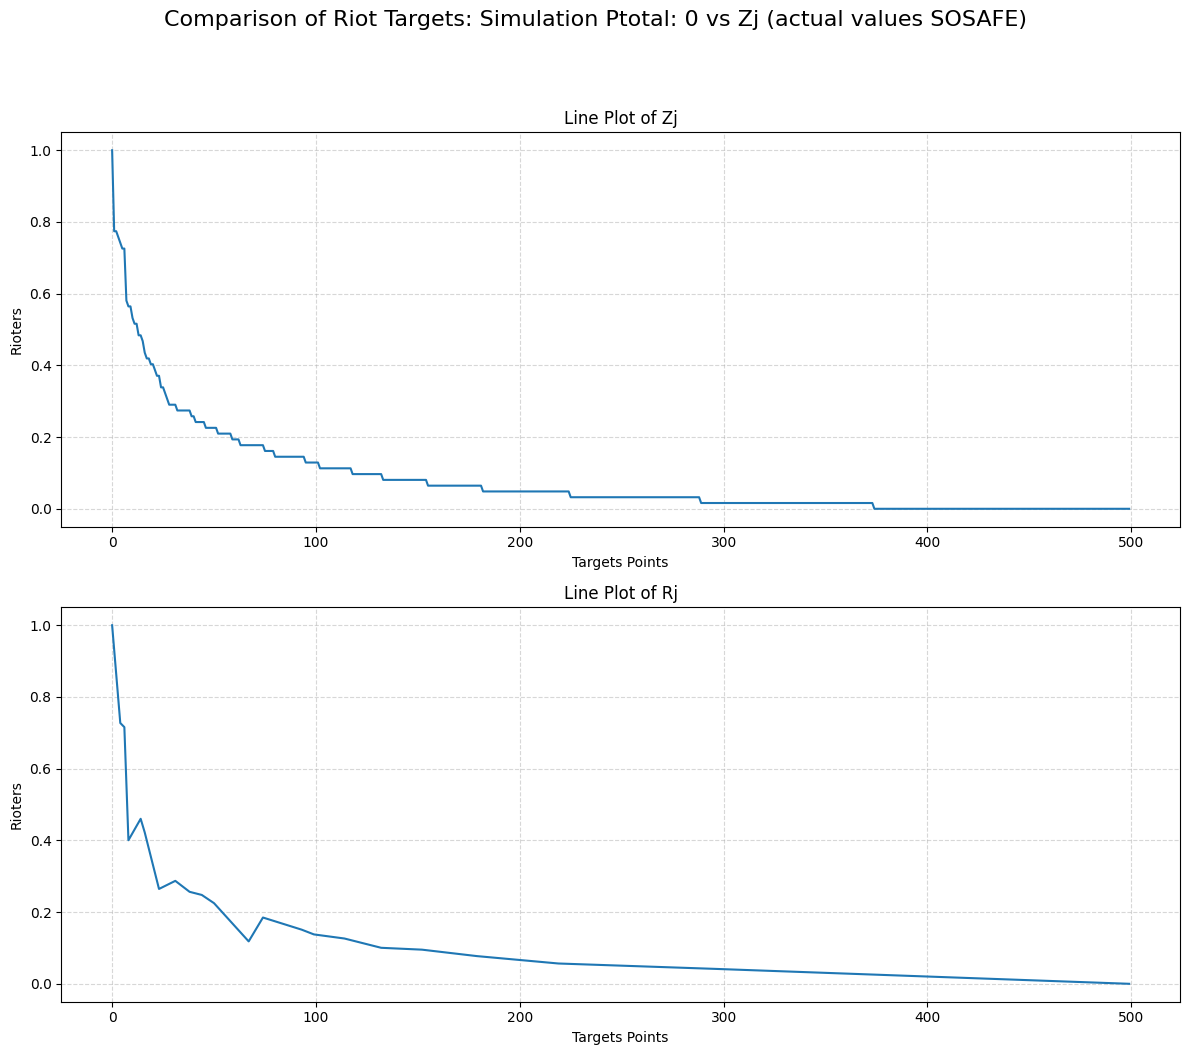

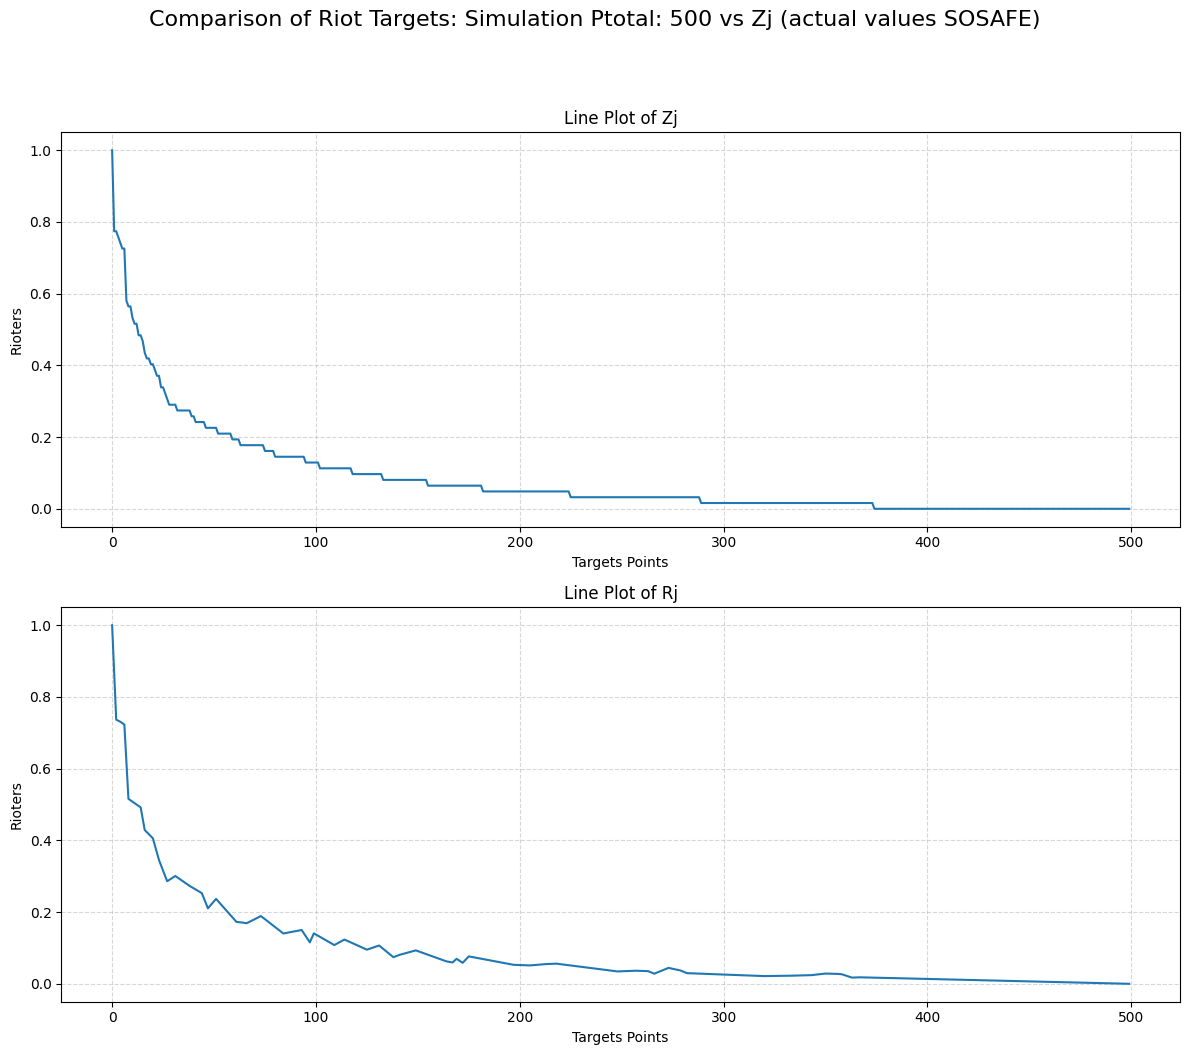

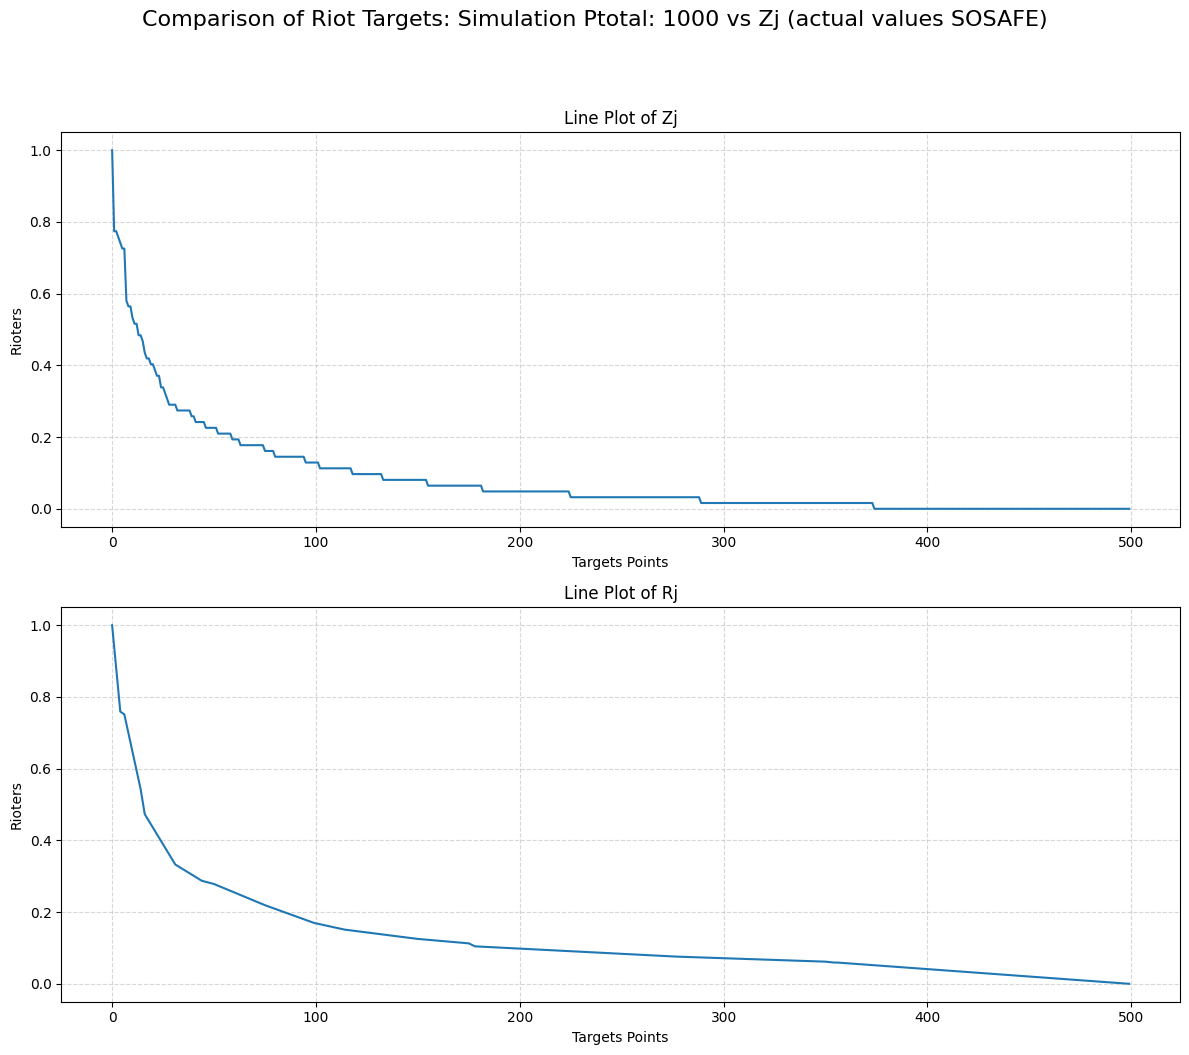

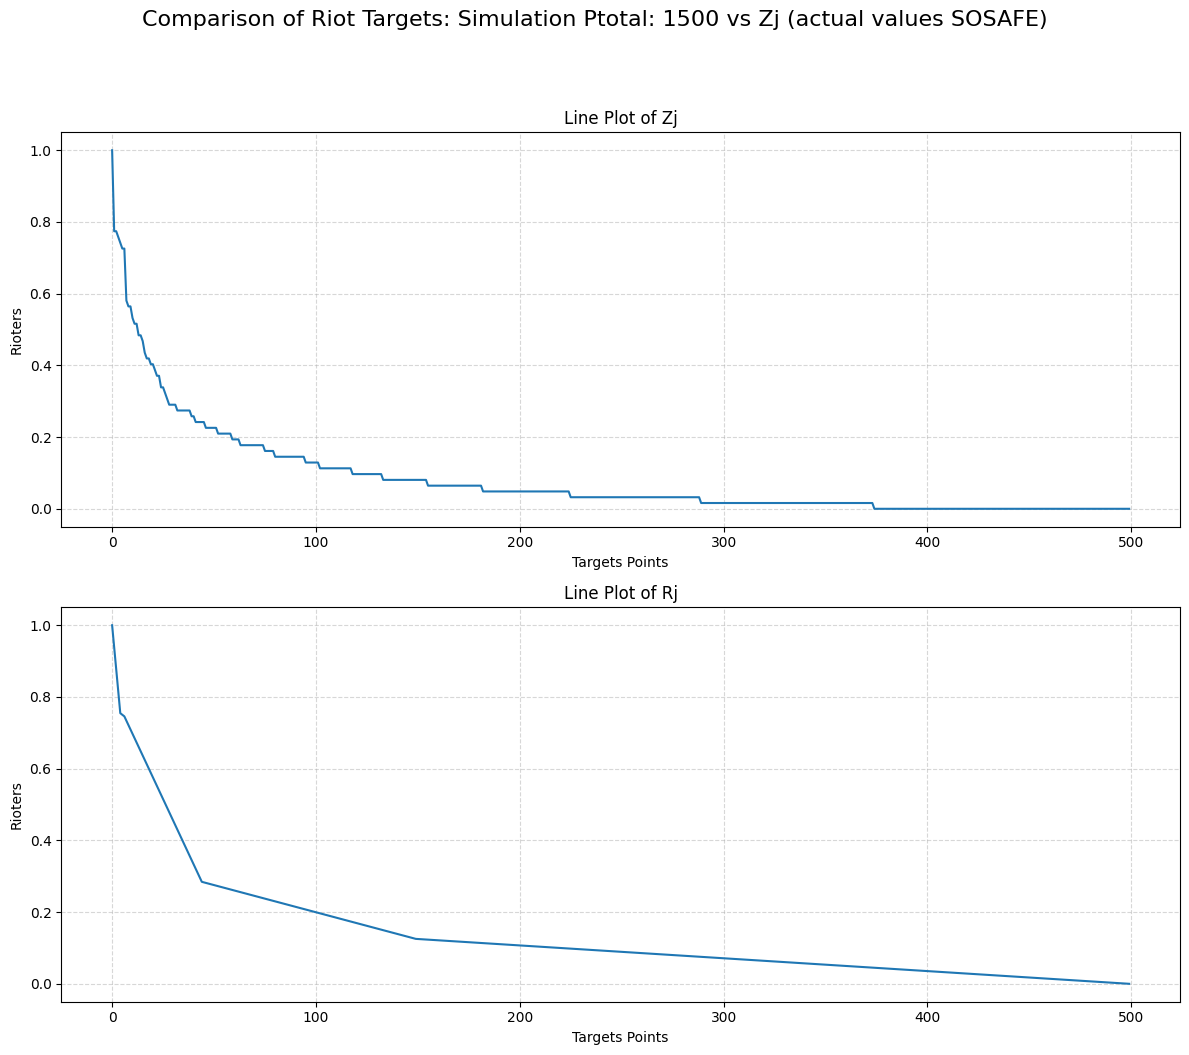

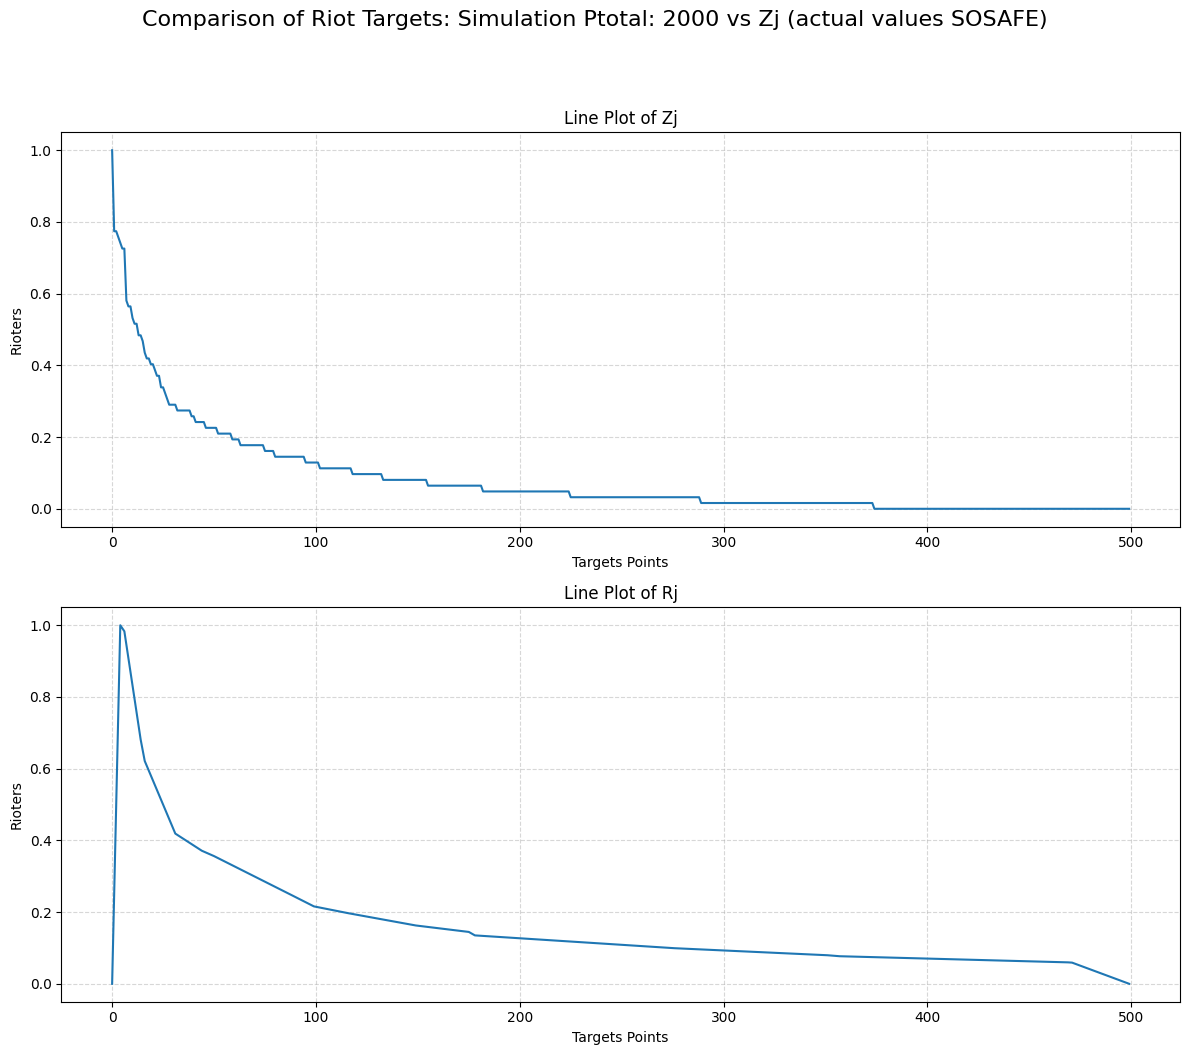

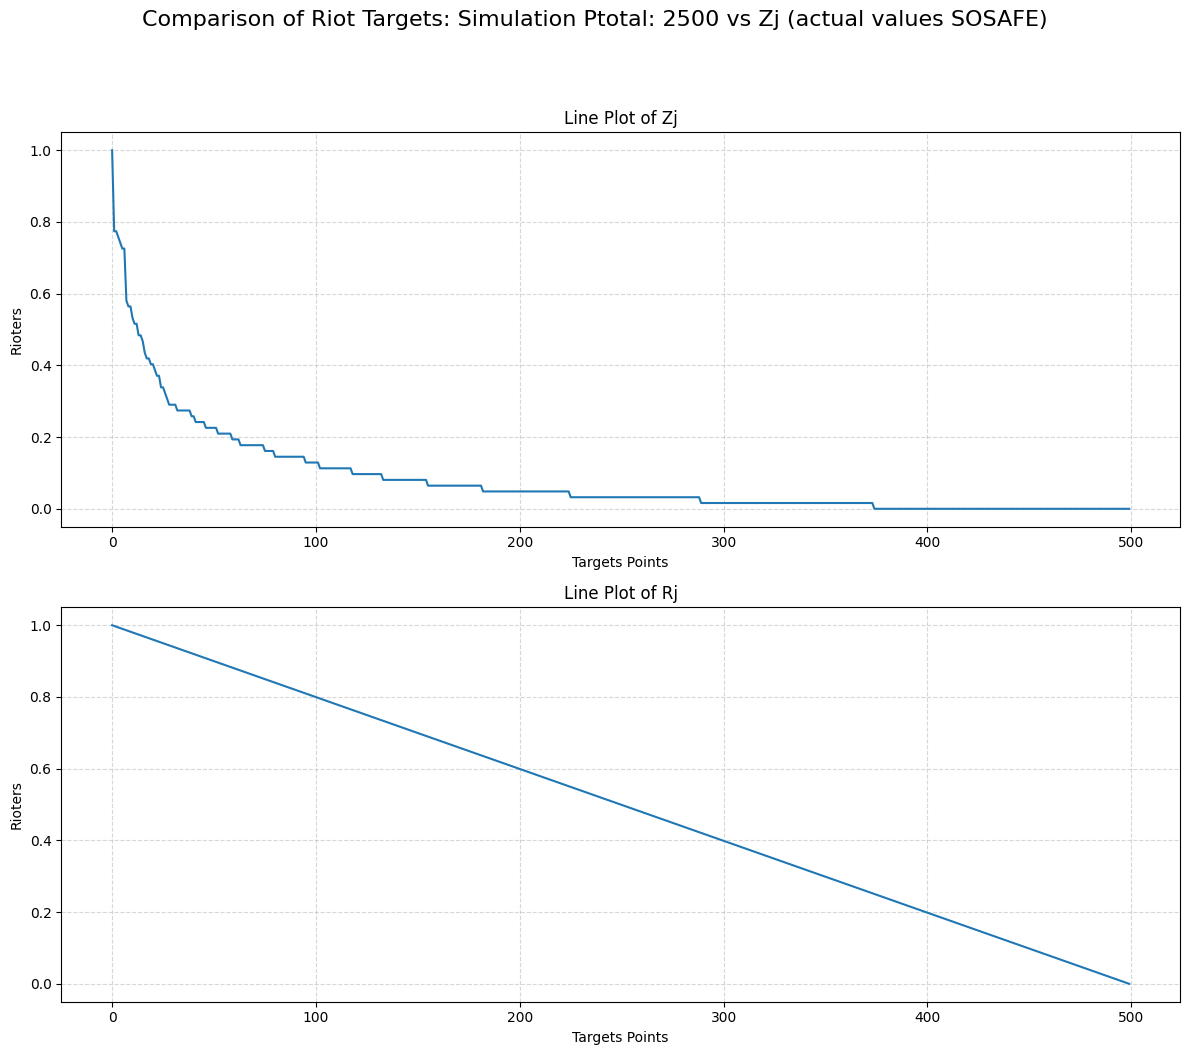

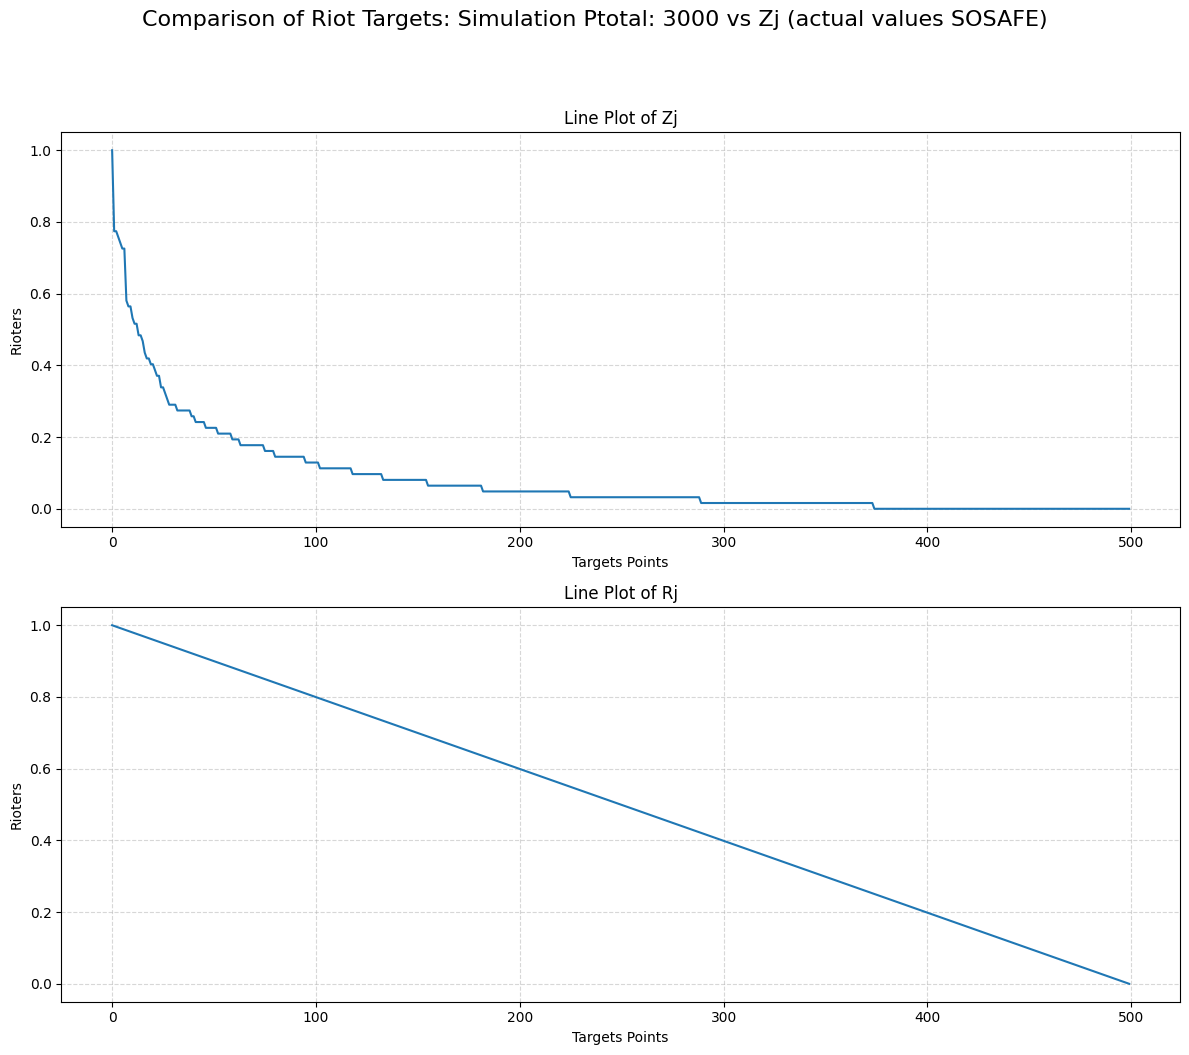

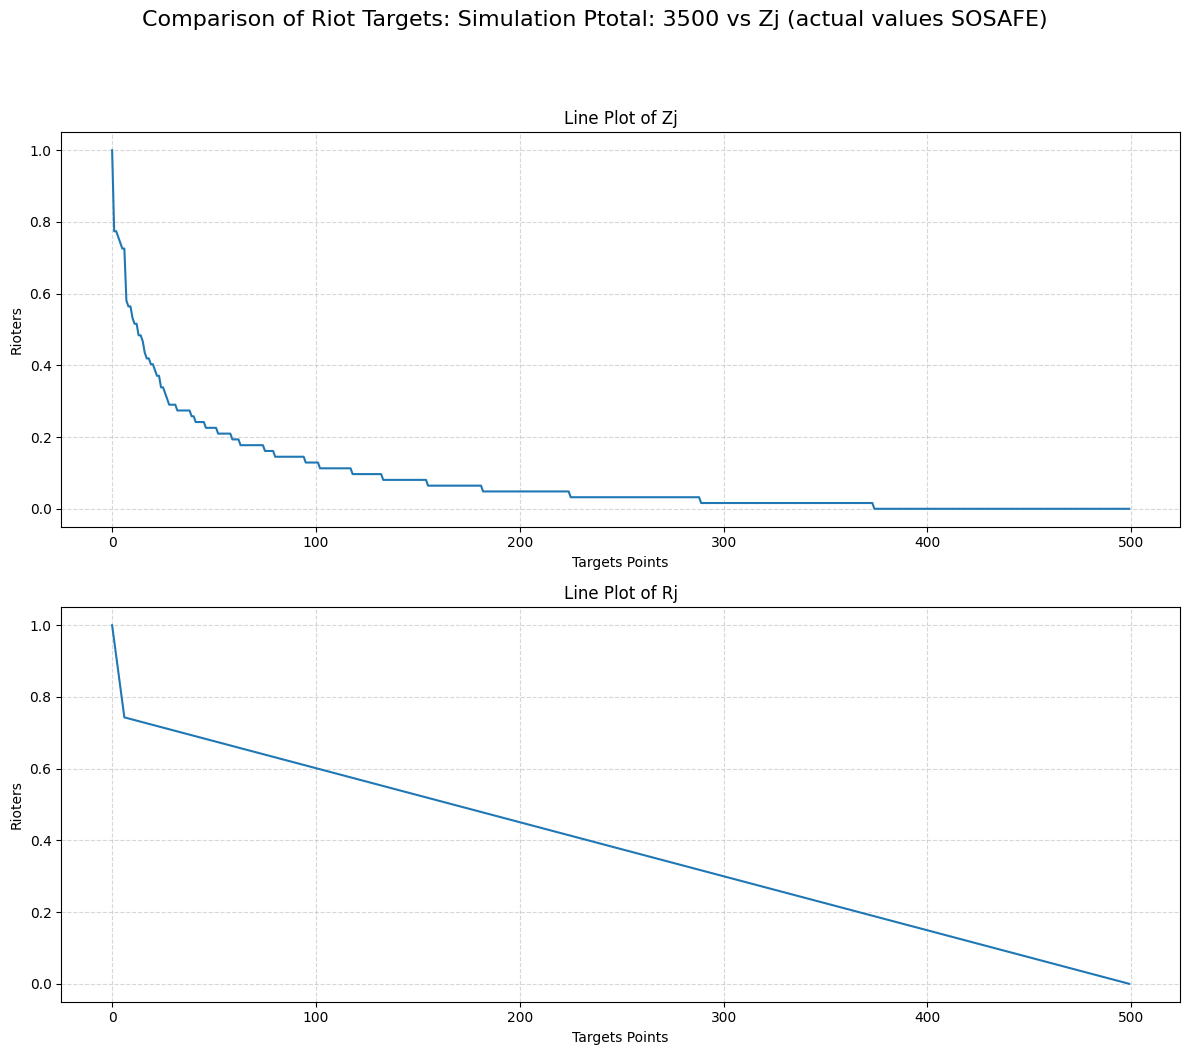

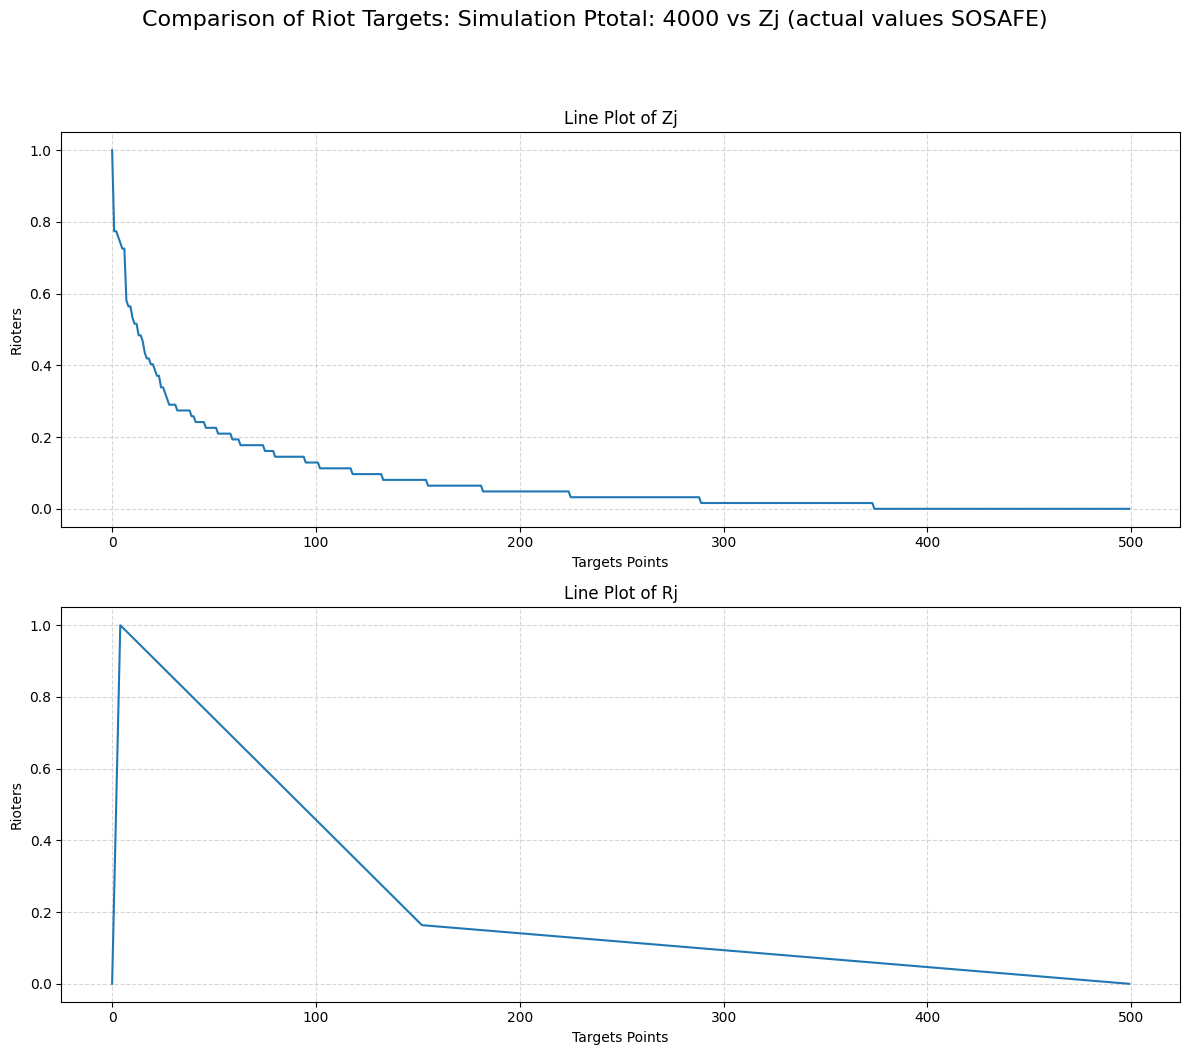

In [ ]:
for i, e in enumerate(Rj_simulated_ptotals): # Plot results
    ptotal_qty = (i)*500
    plot_results(real_scaled_data, e, f"Ptotal: {ptotal_qty}")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import find_peaks

def run_model_simulation(dij_sim, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p, Ptotal):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Zj_t = torch.from_numpy(Zj).to(device)
    Ii_t = torch.from_numpy(Ii).to(device)
    dij_t = torch.from_numpy(dij_sim).to(device)

    Lr, Lp = 6, 12
    eta, tau = 0.005, 0.75
    counter, idxr, idxp, t, dt = 0, 0, 0, 0, 0.1
    Nt, Ntt, nlat, nlon, nz = 500, 10, 78, 71, 500

    # # PSO parameters
    # beta_r = 0.1
    # gamma_r = 0.19482765
    # alpha_p = 0.97356374
    # gamma_p = 0.03415131

    Rj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ai_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    Pj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)
    Ci_t = torch.from_numpy(np.zeros((nlat, nlon), "d")).to(device)
    fjdel_t = torch.from_numpy(np.zeros((nz, Lr), "d")).to(device)
    rho_t = torch.from_numpy(np.ones((nlat, nlon), "d")).to(device)
    Ddel_t = torch.from_numpy(np.zeros((nz, Lp), "d")).to(device)
    Dj_t = torch.from_numpy(np.zeros(nz, "d")).to(device)

    auxij1 = torch.exp(-beta_r * dij_t)
    dij_t = 1.0 * Zj_t[:, 2] * auxij1 / torch.max(Zj_t[:, 2])

    print("Starting loop ...")
    timer0 = time.time()

    for nn in range(Nt):
        for mm in range(Ntt):
            fj_t = torch.exp(-torch.floor(gamma_r * Pj_t / (Rj_t + 1.0e-20))) # 500 Values
            Wij_t = fj_t * dij_t # Dj shape: 78, 71, 500 (Broadcasting) --> Attractiveness term ij
            Wi_t = Wij_t.sum(dim=2) # Wi shape: 78, 71 each value is the sum of 500 values (fj) --> Attractiveness term i
            P_off_t = rho_t * Wi_t / (1.0 + Wi_t) # P_off shape: 78, 71
            idxr = counter - (Lr) * int(counter / Lr) # Lr: 6, idxr: 0-5
            fjdel_t[:, idxr] = fj_t # fjdel: 500, 6
            dnm = Lr if counter >= Lr else counter + 1
            We_ij_t = fjdel_t.sum(dim=1) * dij_t / dnm # Delayed term computation
            auxw = Ai_t / (We_ij_t.sum(dim=2) + 1.0e-20)  # Flow computation step 1i
            Sij_t = auxw[:, :, torch.newaxis] * We_ij_t # Flow computation step 2
            Rj_t = torch.sum(Sij_t.sum(dim=1), dim=0) # Rioter computation
            Dj_t[:] = Zj_t[:, 2] ** (alpha_p) * torch.exp(gamma_p * Rj_t[:]) # Police Interaction
            idxp = counter - (Lp) * int(counter / Lp) # Delayed term computation
            Ddel_t[:, idxp] = Dj_t[:]
            dnm = Lp if counter >= Lp else counter + 1
            Dej_t = torch.sum(Ddel_t, dim=1) / dnm
            Pj_t = float(Ptotal) * Dej_t / Dej_t.sum()
            counter += 1
            fj_t = 1.0 - torch.exp(-torch.floor(Pj_t / (Rj_t + 1.0e-20))) # Capture rate
            Ci_t = tau * torch.sum(Sij_t * fj_t, dim=2)
            Ai_t += dt * (eta * P_off_t * Ii_t - Ci_t) # Time step for Ai and Ii
            Ii_t += -dt * eta * P_off_t * Ii_t
            t += dt

    Rj_t = Rj_t.cpu().numpy() if hasattr(Rj_t, 'cpu') else Rj_t

    x = np.arange(len(Rj_t))
    y = Rj_t

    # Detectar picos
    y_norm = (y - np.min(y)) / (np.max(y) - np.min(y))  # Normalización Min-Max
    peaks, _ = find_peaks(y_norm, prominence=0.05)  # Ajuste según la escala normalizada
    peaks = np.insert(peaks, 0, 0)  # Asegurar que el primer punto sea considerado un pico
    peaks = np.append(peaks, len(y)-1)  # Incluir el último punto también si es necesario

    # Filtrar los valores
    x_peaks = x[peaks]
    y_peaks = y[peaks]

    # Interpolación lineal
    linear_interpolation_Rj = np.interp(x, x_peaks, y_peaks)

    scaler = MinMaxScaler()
    Rj_t_filtered_n_scaled = scaler.fit_transform(linear_interpolation_Rj.reshape(-1, 1)).flatten()

    timer1 = time.time()
    print("Total execution time: ", timer1 - timer0)

    return Rj_t_filtered_n_scaled, Rj_t

In [ ]:
# Initial data arrays
origin = np.loadtxt(f"{FOLDER_PATH}/origin_dens_500m_5am10am.dat") # Origin
destination = np.loadtxt(f"{FOLDER_PATH}/destination_dens_500m_5am10am.dat") # Destination

# Population, Police and Rioters
Ii = origin + destination  # Inactive population (the number of inactive individuals resident in area i)
Zj = np.loadtxt(f"{FOLDER_PATH}/targets_500.dat")  # Targets (Benefit for j site is given by the logarithm of Zj a non-dimensional measure of its relative value)
dij = np.load(f"{FOLDER_PATH}/rij_500_no_network.npy")

# PSO parameters
beta_r = 0.1
gamma_r = 0.19482765
alpha_p = 0.97356374
gamma_p = 0.03415131

In [ ]:
def objective_function(params, dij, Ii, Zj, target_results):
    beta_r, gamma_r, alpha_p, gamma_p, Ptotal = params

    # Simulación con parámetros actuales
    simulation_results = run_model_simulation(dij, Ii, Zj, beta_r, gamma_r, alpha_p, gamma_p, Ptotal)

    # Evaluación de la diferencia con los resultados esperados
    error = np.linalg.norm(simulation_results[0] - target_results)

    print(f"Error: {error}\n")

    return error

In [ ]:
from scipy.optimize import minimize

# Límites de búsqueda para cada parámetro
bounds = [(0.15, 0.25), (0.1, 0.2), (0.09, 1.2), (0.001, 0.02), (0.0, 4000.0)]

# Valores iniciales
initial_params = [0.15, 0.1, 0.09, 0.001, 0.0]

# Optimización con descenso de gradiente
result_gd = minimize(objective_function, initial_params, args=(dij, Ii, Zj, real_scaled_data), bounds=bounds, method='L-BFGS-B')

print("Parámetros óptimos encontrados:", result_gd.x)
print("Error final:", result_gd.fun)

Starting loop ...
Total execution time:  3.3847694396972656
Error: 0.44376159024588113

Starting loop ...
Total execution time:  3.3727335929870605
Error: 0.4437616050268606

Starting loop ...
Total execution time:  3.3538501262664795
Error: 0.44376159024588113

Starting loop ...
Total execution time:  3.4195892810821533
Error: 0.44376159024588113

Starting loop ...
Total execution time:  3.362910747528076
Error: 0.44376159024588113

Starting loop ...
Total execution time:  3.3460774421691895
Error: 0.4437605398740061

Starting loop ...
Total execution time:  3.348198890686035
Error: 0.43667039256979107

Starting loop ...
Total execution time:  3.355707883834839
Error: 0.4366704039381952

Starting loop ...
Total execution time:  3.361453056335449
Error: 0.43667039256979107

Starting loop ...
Total execution time:  3.374901294708252
Error: 0.43667039256979107

Starting loop ...
Total execution time:  3.3733136653900146
Error: 0.43667039256979107

Starting loop ...
Total execution time: 

In [ ]:
beta_r_opt, gamma_r_opt, alpha_p_opt, gamma_p_opt, Ptotal_opt = result_gd.x[0], result_gd.x[1], result_gd.x[2], result_gd.x[3], result_gd.x[4]
Rj_simulated_GD = run_model_simulation(dij, Ii, Zj, beta_r_opt, gamma_r_opt, alpha_p_opt, gamma_p_opt, Ptotal_opt)

Starting loop ...
Total execution time:  3.3569188117980957


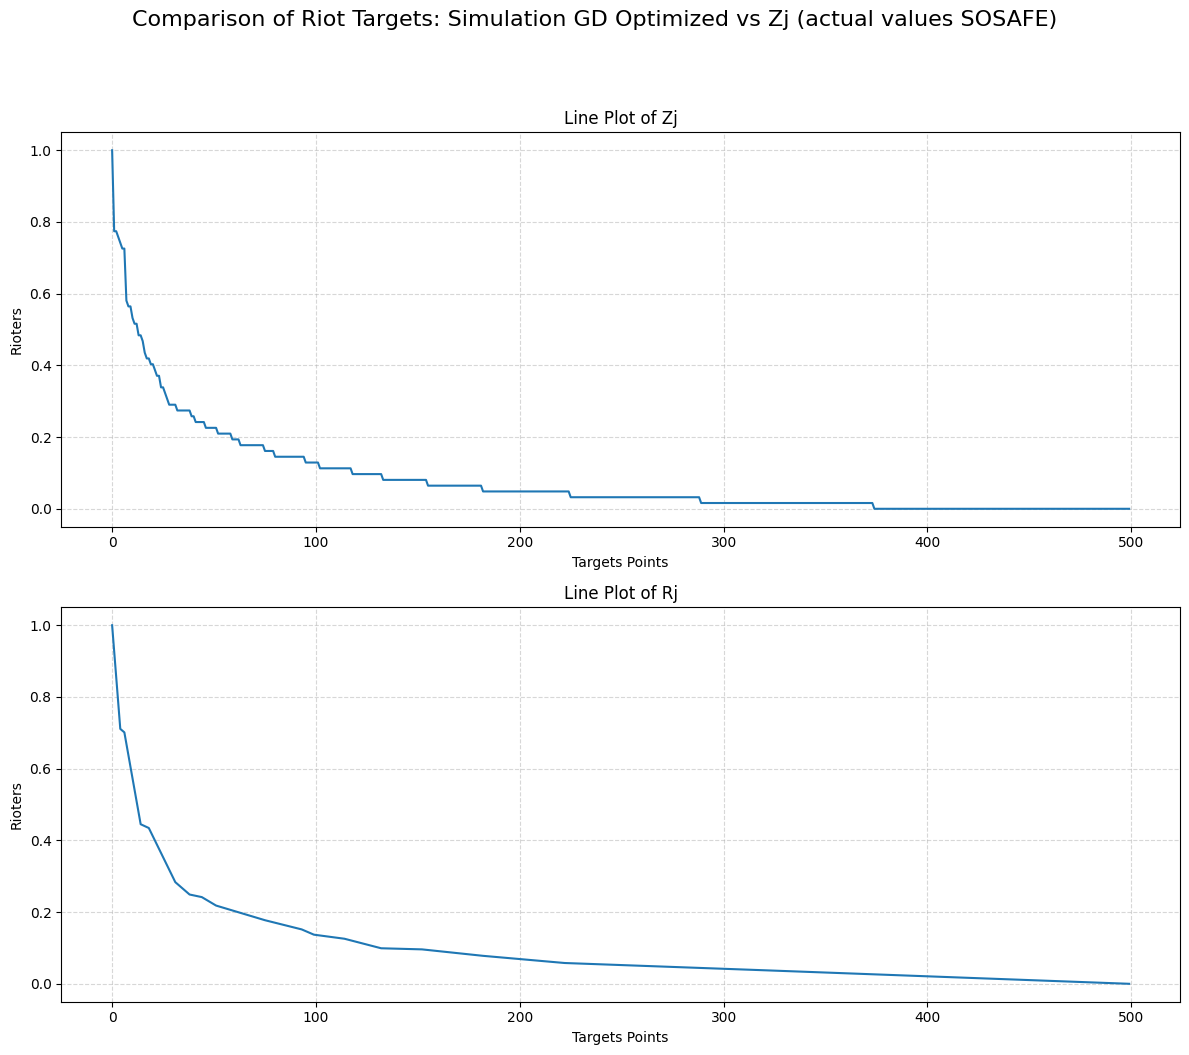

In [ ]:
plot_results(real_scaled_data, Rj_simulated_GD[0], 'GD Optimized')

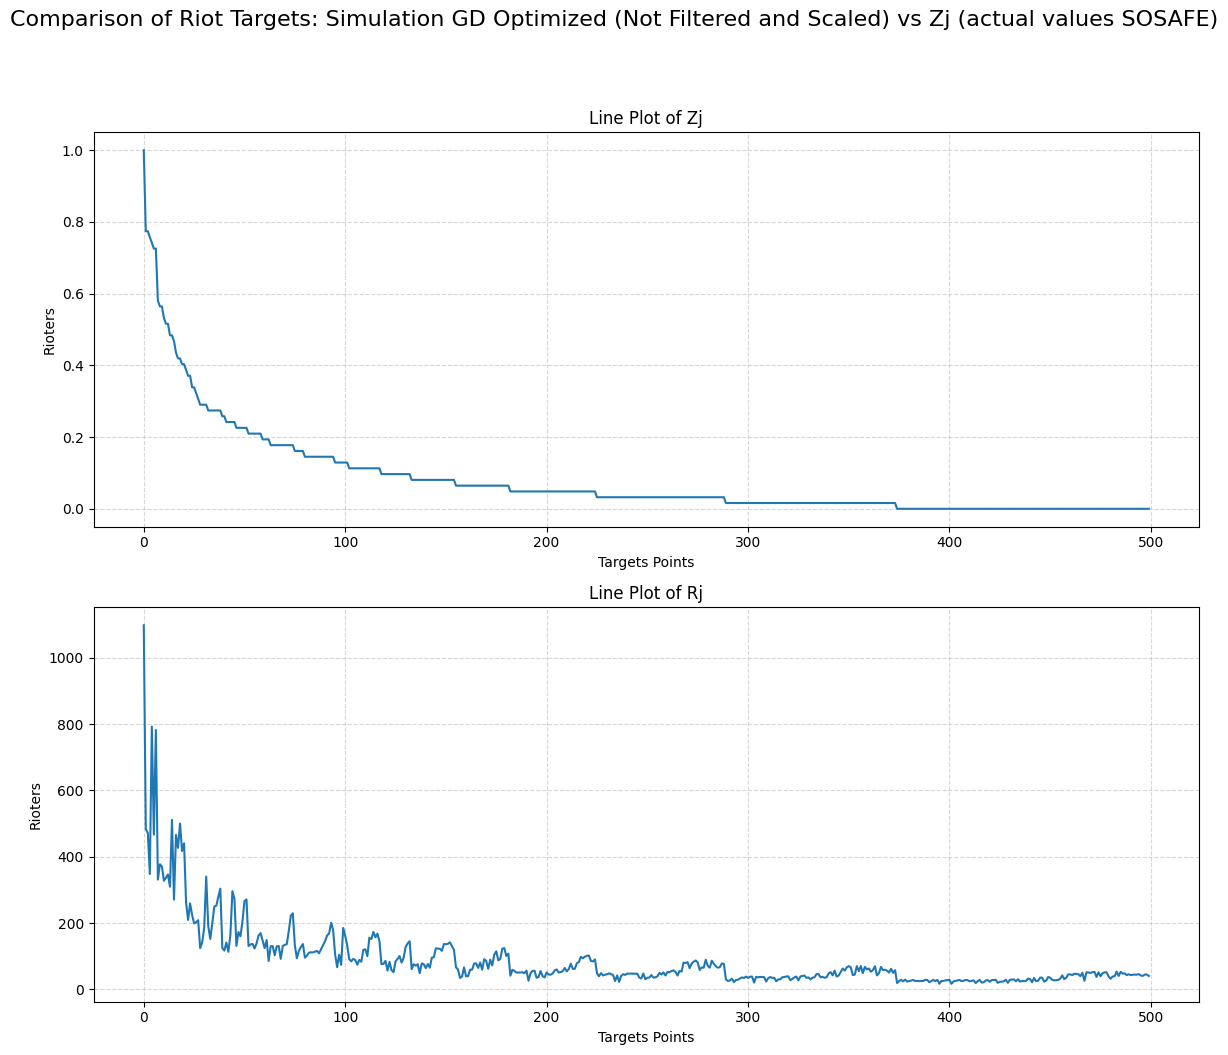

In [ ]:
plot_results(real_scaled_data, Rj_simulated_GD[1], 'GD Optimized (Not Filtered and Scaled)')

In [ ]:
print("GD Results")
print_detailed_comparison_sklearn(Rj_simulated_GD[0], real_scaled_data)

GD Results
Métricas de error:
RMSE: 0.0198
MAE: 0.0167
MAPE mod: 47.97%
SMAPE: 75.29%
R² Score: 0.9779
Error máximo: 0.1536


In [ ]:
print("GD Results without Interpolation")
print_detailed_comparison_sklearn(Rj_simulated_GD[1], real_scaled_data)

GD Results without Interpolation
Métricas de error:
RMSE: 136.2951
MAE: 88.7627
MAPE mod: 150174.59%
SMAPE: 199.74%
R² Score: -1040940.6269
Error máximo: 1096.8117
